<a href="https://colab.research.google.com/github/tangguhal/rayyan/blob/main/Deep_Dive_Analysis_Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup Packages

In [ ]:
%pip install scipy==1.11.4
%pip install dalex
%pip install scikit-plot
%pip install shap
%pip install lime


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
import lightgbm as lgb
# decision tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import cross_val_score,cross_val_predict, train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer,LabelEncoder

# import tree module
from sklearn import tree
# import dalex to explain complex model
import dalex as dx

# load shap package for shap explanation
import shap

# load LimeTabularExplainer for LIME method
from lime.lime_tabular import LimeTabularExplainer

from sklearn.metrics import accuracy_score,classification_report, recall_score,confusion_matrix, roc_auc_score, precision_score, f1_score, roc_curve, auc

## Load Dataset

In [ ]:
df = pd.read_csv("telco_customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Understanding
```
1. CustomerID = Contains unique values from every customer
2. Gender = Male and Female
3. SeniorCitizen = 1 for yes and 0 for no
4. Partner = Whether the customer has a partner (1) or no (0)
5. Dependents = Whether the customer has dependents or not (Yes, No)
6. tenure = Number of months the customer has stayed with the company
7. PhoneService = Whether the customer has a phone service or not (Yes, No)
8. MultipleLines = Whether the customer has multiple lines or not (Yes, No, No phone service)
9. InternetService = Customer’s internet service provider (DSL, Fiber optic, No)
10. OnlineSecurity = Whether the customer has online security or not (Yes, No, No internet service)
11. OnlineBackup = Whether the customer has online backup or not (Yes, No, No internet service)
12. DeviceProtection = Whether the customer has device protection or not (Yes, No, No internet service)
13. TechSupport = Whether the customer has tech support or not (Yes, No, No internet service)
14. StreamingTV = Whether the customer has streaming TV or not (Yes, No, No internet service)
15. StreamingMovies = Whether the customer has streaming movies or not (Yes, No, No internet service)
16. Contract = The contract term of the customer (Month-to-month, One year, Two year)
17. PaperlessBilling = Whether the customer has paperless billing or not (Yes, No)
18. PaymentMethod = The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
19. MonthlyCharges = The amount charged to the customer monthly
20. TotalCharges = The total amount charged to the customer
21. Churn = Whether the customer churned or not (Yes or No)
```



## Data Preprocessing

### Data Cleaning

- Missing Values :
  - Kalo dibawah 5% -> Drop (Total data)
  - Kalo 5 - 20% -> imputasi (Nanya!, Diskusi, Statistik)
  - diatas 20% -> kolom gak dipake/ survey ulang/ isi
- Duplicated
  - Wajib dihapus
- Data Types
  - Disesuaikan data dengan tipe yang diinginkan

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Checking unique values
attFeatures = []
for i in df.columns:
    attFeatures.append([i,df[i].dtype, df[i].nunique(), df[i].sort_values().drop_duplicates().values])
pd.DataFrame(attFeatures, columns = ['Features','Type', 'Unique Number', 'Values'])

,Features,Type,Unique Number,Values
0,customerID,object,7043,"[0002-ORFBO, 0003-MKNFE, 0004-TLHLJ, 0011-IGKF..."
1,gender,object,2,"[Female, Male]"
2,SeniorCitizen,int64,2,"[0, 1]"
3,Partner,object,2,"[No, Yes]"
4,Dependents,object,2,"[No, Yes]"
5,tenure,int64,73,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
6,PhoneService,object,2,"[No, Yes]"
7,MultipleLines,object,3,"[No, No phone service, Yes]"
8,InternetService,object,3,"[DSL, Fiber optic, No]"
9,OnlineSecurity,object,3,"[No, No internet service, Yes]"


In [ ]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.isna().sum()/len(df)*100

,0
customerID,0.000000
gender,0.000000
SeniorCitizen,0.000000
Partner,0.000000
Dependents,0.000000
tenure,0.000000
PhoneService,0.000000
MultipleLines,0.000000
InternetService,0.000000
OnlineSecurity,0.000000


In [ ]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Kemungkinan total charges NaN dikarenakan pelanggan baru bergabung

In [ ]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Checking Duplicates
df.duplicated().sum()

0

### Feature Selection
Memilih fitur-fitur yang tepat untuk memprediksi target

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [ ]:
# Drop customer ID columns
df = df.drop('customerID', axis=1)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Encoding

In [ ]:
categorical_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,Female,0,Yes,No,1,No,DSL,Month-to-month,Yes,Electronic check,29.85,29.85,No,True,False,False,False,False,True,False,False,False,False,False,False,False,False
1,Male,0,No,No,34,Yes,DSL,One year,No,Mailed check,56.95,1889.50,No,False,False,False,True,False,False,False,True,False,False,False,False,False,False
2,Male,0,No,No,2,Yes,DSL,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,False,False,False,True,False,True,False,False,False,False,False,False,False,False
3,Male,0,No,No,45,No,DSL,One year,No,Bank transfer (automatic),42.30,1840.75,No,True,False,False,True,False,False,False,True,False,True,False,False,False,False
4,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Drop every columns with no internet service in it
df.drop(['OnlineBackup_No internet service',
         'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service',
         'StreamingMovies_No internet service'], axis=1, inplace=True)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
0,Female,0,Yes,No,1,No,DSL,Month-to-month,Yes,Electronic check,29.85,29.85,No,True,False,False,False,True,False,False,False,False
1,Male,0,No,No,34,Yes,DSL,One year,No,Mailed check,56.95,1889.50,No,False,False,False,True,False,True,False,False,False
2,Male,0,No,No,2,Yes,DSL,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,False,False,False,True,True,False,False,False,False
3,Male,0,No,No,45,No,DSL,One year,No,Bank transfer (automatic),42.30,1840.75,No,True,False,False,True,False,True,True,False,False
4,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,False,False,False,False,False,False,False,False,False


In [ ]:
# Replace 'OnlineSecurity_No internet service' to 'No internet service'
df['No_internet_service'] = df['OnlineSecurity_No internet service'].replace(1, 0)

In [ ]:
# One Hot Encoding before splitting
InternetHot = pd.get_dummies(df['InternetService'],prefix='Internet')
InternetHot = InternetHot.astype(int)
PaymentHot = pd.get_dummies(df['PaymentMethod'],prefix='Payment')
PaymentHot = PaymentHot.astype(int)
df = pd.concat([df, InternetHot, PaymentHot], axis=1)

df.drop('InternetService', axis=1, inplace=True)
df.drop('PaymentMethod', axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,No_internet_service,Internet_DSL,Internet_Fiber optic,Internet_No,Payment_Bank transfer (automatic),Payment_Credit card (automatic),Payment_Electronic check,Payment_Mailed check
0,Female,0,Yes,No,1,No,Month-to-month,Yes,29.85,29.85,No,True,False,False,False,True,False,False,False,False,False,1,0,0,0,0,1,0
1,Male,0,No,No,34,Yes,One year,No,56.95,1889.50,No,False,False,False,True,False,True,False,False,False,False,1,0,0,0,0,0,1
2,Male,0,No,No,2,Yes,Month-to-month,Yes,53.85,108.15,Yes,False,False,False,True,True,False,False,False,False,False,1,0,0,0,0,0,1
3,Male,0,No,No,45,No,One year,No,42.30,1840.75,No,True,False,False,True,False,True,True,False,False,False,1,0,0,1,0,0,0
4,Female,0,No,No,2,Yes,Month-to-month,Yes,70.70,151.65,Yes,False,False,False,False,False,False,False,False,False,False,0,1,0,0,0,1,0


In [ ]:
# Ordinal encoding for Contract
contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_mapping)

In [ ]:
encode = ['gender', 'Partner', 'Dependents', 'PhoneService','PaperlessBilling', 'Churn']

le = LabelEncoder()
for col in encode:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,No_internet_service,Internet_DSL,Internet_Fiber optic,Internet_No,Payment_Bank transfer (automatic),Payment_Credit card (automatic),Payment_Electronic check,Payment_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,0,True,False,False,False,True,False,False,False,False,False,1,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,56.95,1889.50,0,False,False,False,True,False,True,False,False,False,False,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,53.85,108.15,1,False,False,False,True,True,False,False,False,False,False,1,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,42.30,1840.75,0,True,False,False,True,False,True,True,False,False,False,1,0,0,1,0,0,0
4,0,0,0,0,2,1,0,1,70.70,151.65,1,False,False,False,False,False,False,False,False,False,False,0,1,0,0,0,1,0


In [ ]:
df = df.astype(float)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,No_internet_service,Internet_DSL,Internet_Fiber optic,Internet_No,Payment_Bank transfer (automatic),Payment_Credit card (automatic),Payment_Electronic check,Payment_Mailed check
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,29.85,29.85,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,34.0,1.0,1.0,0.0,56.95,1889.50,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,53.85,108.15,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,45.0,0.0,1.0,0.0,42.30,1840.75,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,70.70,151.65,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Data Splitting

In [ ]:
# Data Split
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1) # Features
y = df['Churn'] # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data
- Fitur
    - Train 80%
    - Test 20%
- Target
    - Train 80%
    - Test 20%

In [ ]:
X_train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6030,2027-OAQQC,Female,0,No,No,43,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),49.05,2076.20
3410,4918-QLLIW,Male,0,No,No,3,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Credit card (automatic),53.40,188.70
5483,5536-SLHPM,Female,0,Yes,No,55,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,77.75,4458.15
5524,1716-LSAMB,Male,0,Yes,Yes,45,Yes,No,DSL,Yes,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),54.65,2553.70
6337,2696-ECXKC,Female,0,Yes,Yes,55,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,One year,No,Mailed check,100.90,5448.60


Memprediksi

Train - Test
Train = Data untuk machine learning belajar
Test = Untuk validasi performa machine learning

Data Train -> Machine Learning
Machine Learning -> Data Test
20 - 30% untuk test

## EDA

In [ ]:
# Merging X_train and y_train for EDA
df_train = pd.concat([X_train, y_train], axis=1)

### Churning Analysis

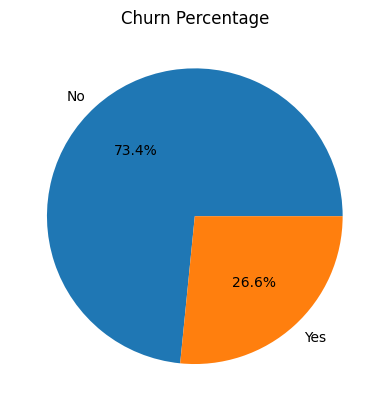

In [ ]:
# Churn Percentage using pie chart
plt.pie(df_train['Churn'].value_counts(), labels=df_train['Churn'].value_counts().index, autopct='%1.1f%%')
plt.title('Churn Percentage')
plt.show()

In [ ]:
df_train['Churn'].value_counts()

,count
Churn,
No,4130
Yes,1495


We Have Imbalanced dataset

### How Contract affect Churn

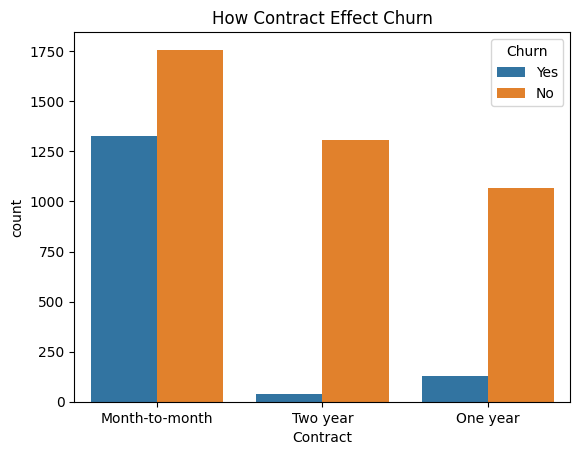

In [ ]:
# Analyze how contract effect churn
sns.countplot(data=df_train, x='Contract', hue='Churn')
plt.title('How Contract Effect Churn')
plt.show()

In [ ]:
# Analyze Churn potential based on Contract
ChurnbyContract = pd.crosstab(df['Churn'], df['Contract']).apply(lambda x: x/x.sum()*100)
ChurnbyContract

Contract,Month-to-month,One year,Two year
Churn,,,
No,57.290323,88.722826,97.151335
Yes,42.709677,11.277174,2.848665


In [ ]:
# how many month to month customer churn?
mtmperc = df_train[df_train['Contract'] == 'Month-to-month']['Churn'].value_counts()/len(df_train[df_train['Churn'] == 'Yes'])*100
mtmperc[1]

88.89632107023412

**Insight**
1. The longer the subscription period, the lower the likelihood of Churn.
2. **42% of MTM Customers churn. And It's 89% from all of the churn customer**
3. only **2.8% of customers churn within two years.**

#### The correlation between MtM contract and Partner and Dependents

In [ ]:
# Analyze Contract Month-to-Month and Churn 'Yes' by Partner and Dependent
df_mtm = df_train[(df_train['Contract'] == 'Month-to-month') & (df_train['Churn'] == 'Yes')]
df_mtm = df_mtm.groupby([
    'Partner','Dependents'
    ]).agg({
        'Churn':'count'}).reset_index().rename(columns={'Churn':'TotalChurn'})
df_mtm['Churn_Percent'] = df_mtm['TotalChurn']/len(df_train[df_train['Churn'] == 'Yes'])*100
df_mtm['Churn_Percent'] = df_mtm['Churn_Percent'].round(2)
df_mtm

,Partner,Dependents,TotalChurn,Churn_Percent
0,No,No,841,56.25
1,No,Yes,53,3.55
2,Yes,No,285,19.06
3,Yes,Yes,150,10.03


**Insight:**

1. **We got a new cluster of customer! They choose MtM contract, They don't have partner and Dependents! But 56% of the churn customer comes from this segment!!!**
2. The customer with MtM contract, no partner but have Dependents surprisingly reduce churn percentage!


#### How MtM contract correlation with other numerical features

In [ ]:
mtm = df_train[
    (df_train['Contract'] == 'Month-to-month') & (df_train['Churn'] == 'Yes')
]

# Grouping and aggregating
mtm = mtm.groupby(['Partner', 'Dependents']).agg({
    'tenure': 'mean',   # Calculate mean tenure
    'MonthlyCharges': 'mean',  # Calculate mean MonthlyCharges
    'TotalCharges': 'mean', # Calculate mean TotalCharges
    'Churn': 'count',  # Count total churn
}).reset_index()

# Renaming columns
mtm = mtm.rename(columns={'Churn': 'TotalChurn'})

# Display the result
mtm

,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,TotalChurn
0,No,No,10.840666,70.906897,880.152556,841
1,No,Yes,7.792453,65.994340,531.535849,53
2,Yes,No,21.915789,80.923158,1899.889123,285
3,Yes,Yes,19.093333,73.677667,1607.726333,150


The tenure, monthly charges and total charges is quite small, but looks like they are not a significant factor for churn.

#### MtM contract vs Senior Citizen

In [ ]:
#MtM contract vs Senior Citizen
df_mtm = df_train[(df_train['Contract'] == 'Month-to-month') & (df_train['Churn'] == 'Yes')]
df_mtm = df_mtm.groupby([
    'SeniorCitizen'
    ]).agg({
        'Churn':'count'}).reset_index().rename(columns={'Churn':'TotalChurn'})
df_mtm['Churn_Percent'] = df_mtm['TotalChurn']/len(df_train[df_train['Churn'] == 'Yes'])*100
df_mtm['Churn_Percent'] = df_mtm['Churn_Percent'].round(2)
df_mtm

,SeniorCitizen,TotalChurn,Churn_Percent
0,0,967,64.68
1,1,362,24.21


We see that most of the MtM Churn Customer comes from the younger age.


Perbandingan kolom numerik dengan Churn:


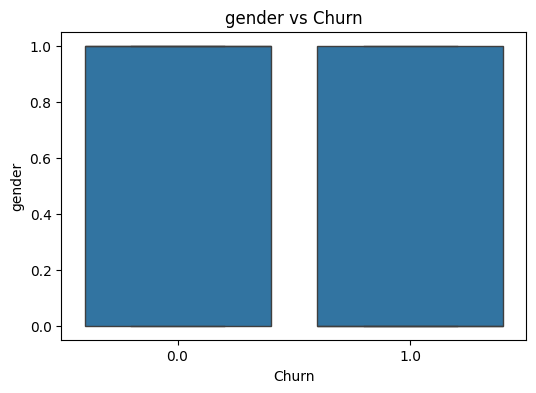

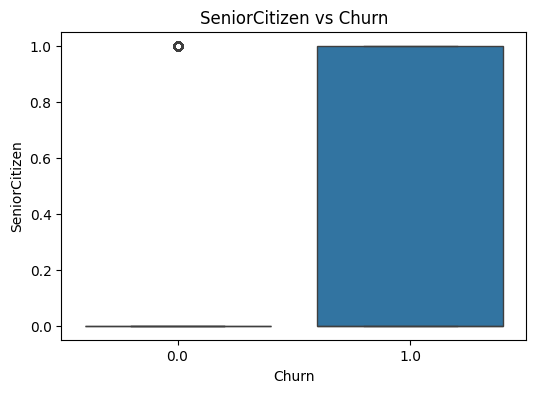

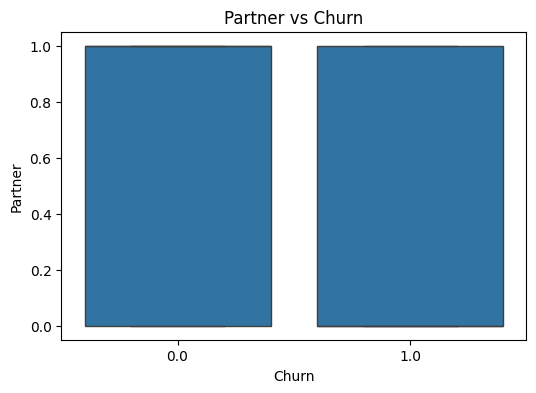

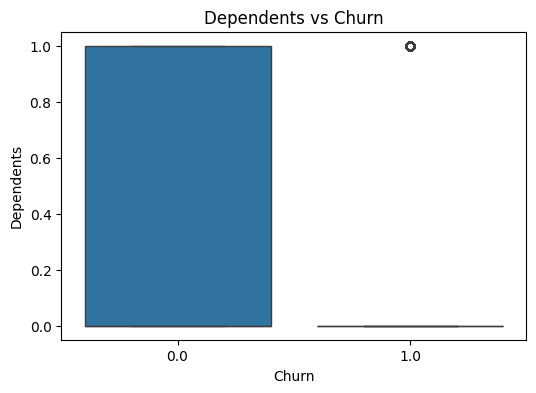

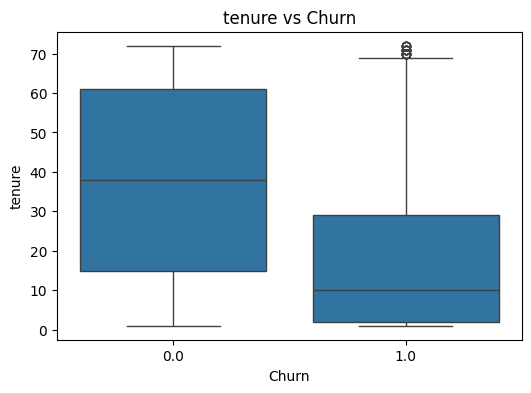

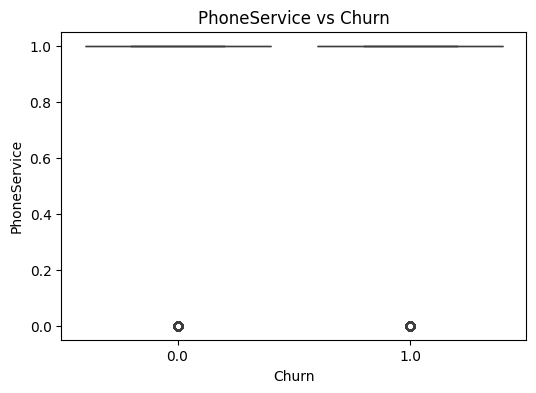

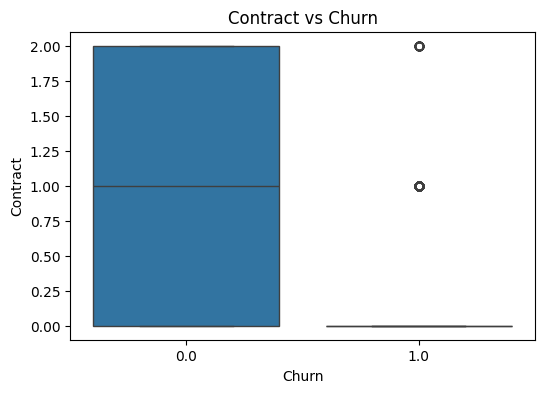

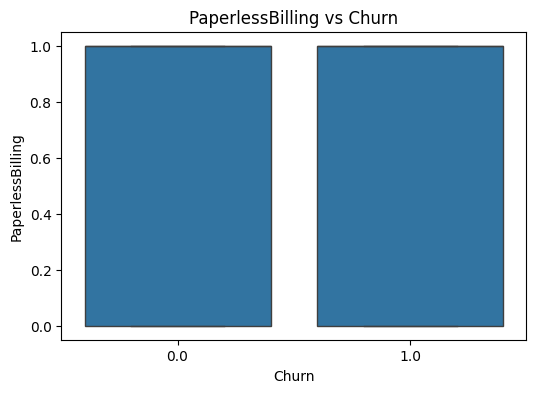

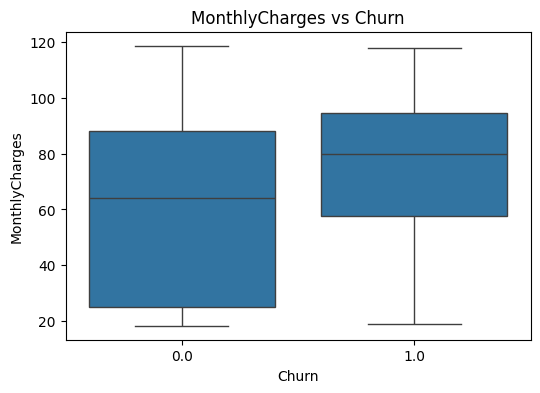

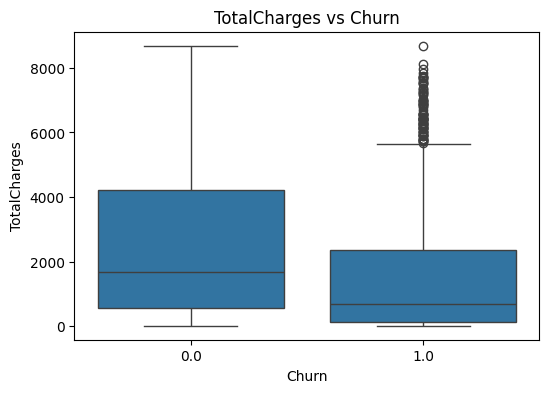

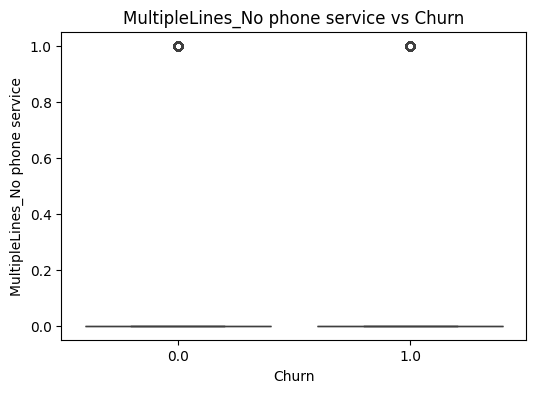

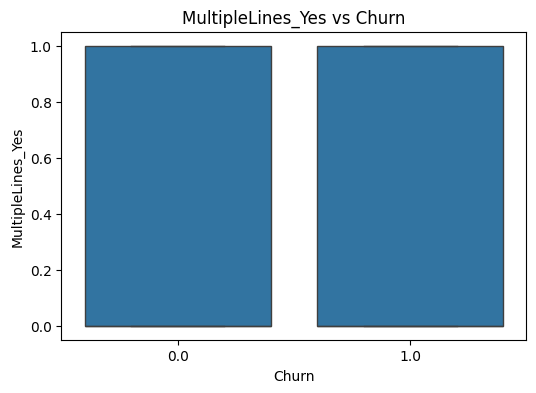

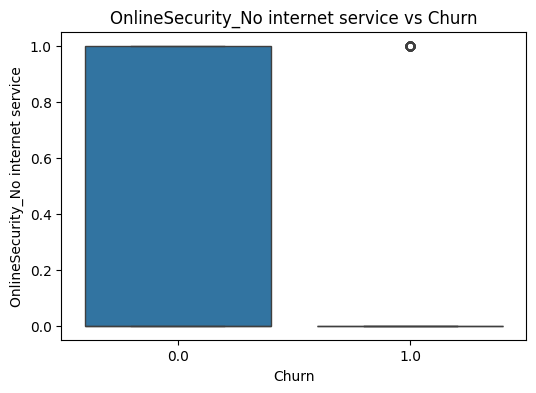

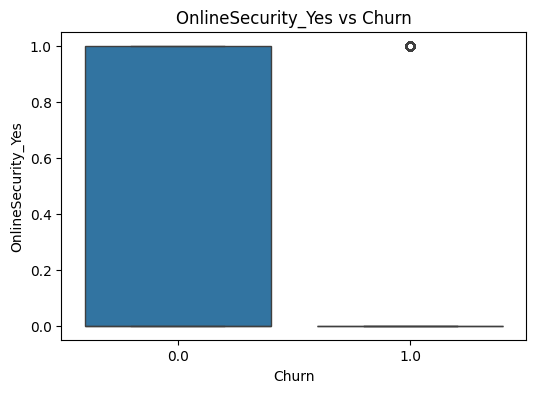

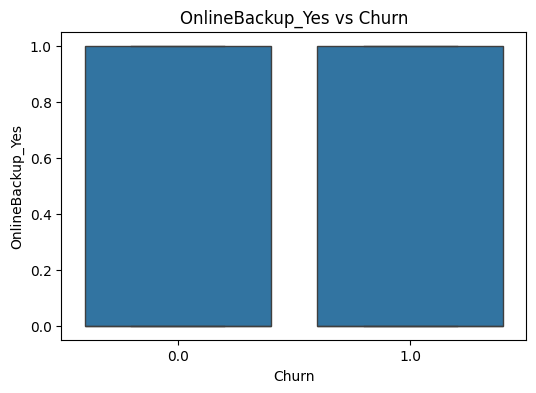

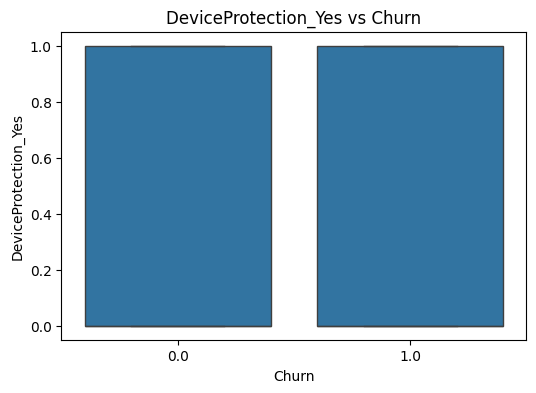

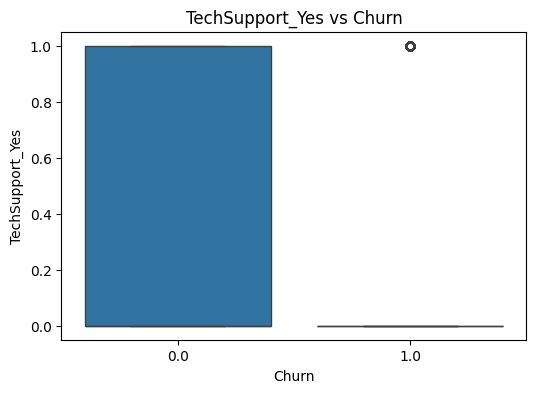

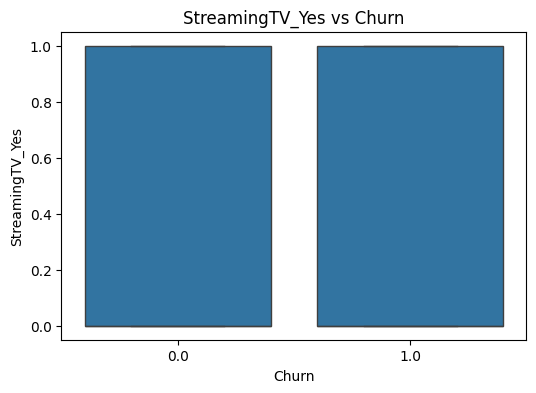

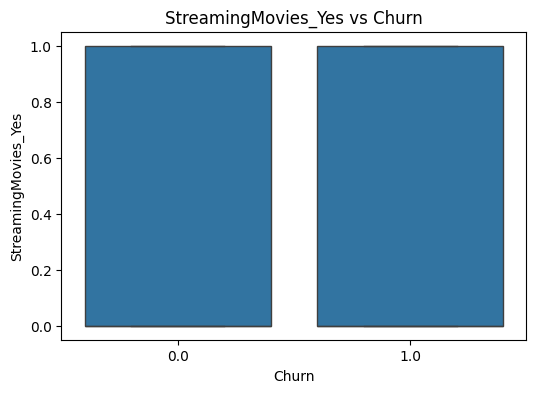

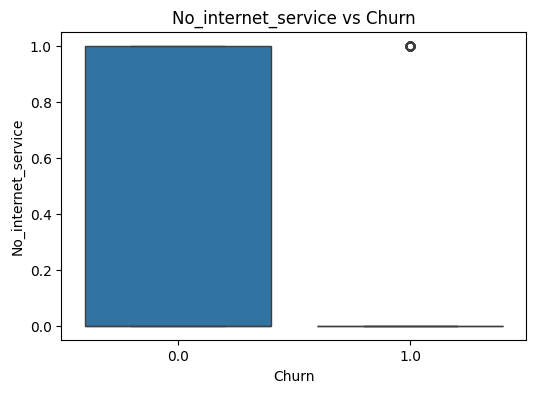

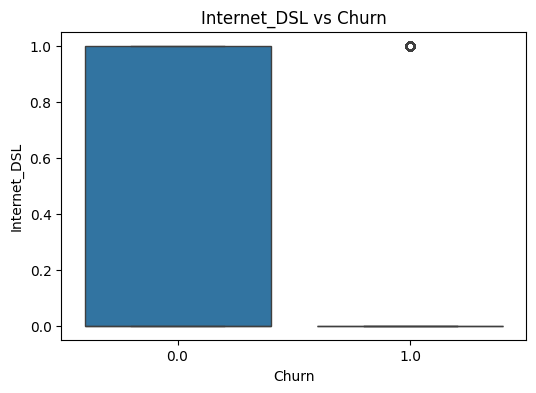

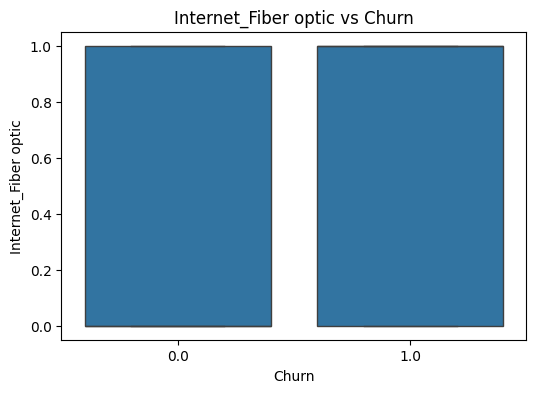

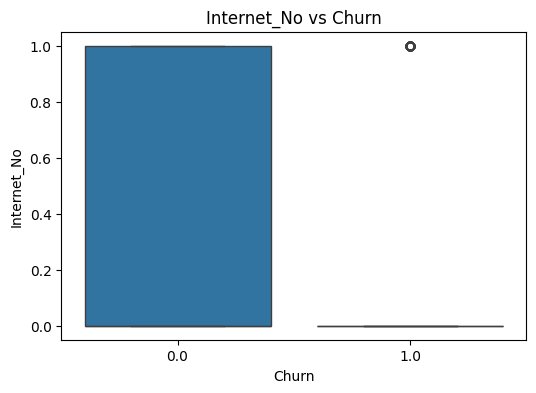

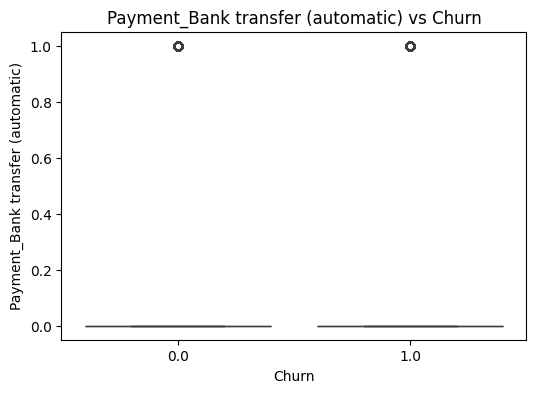

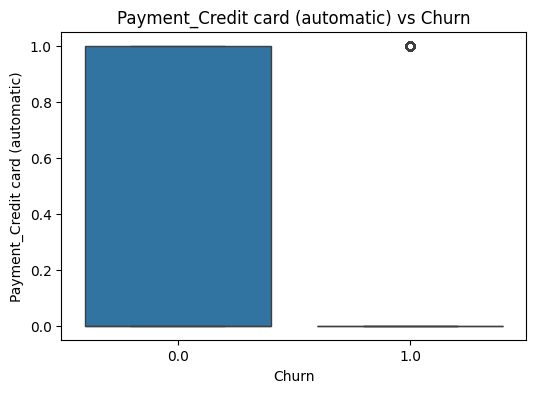

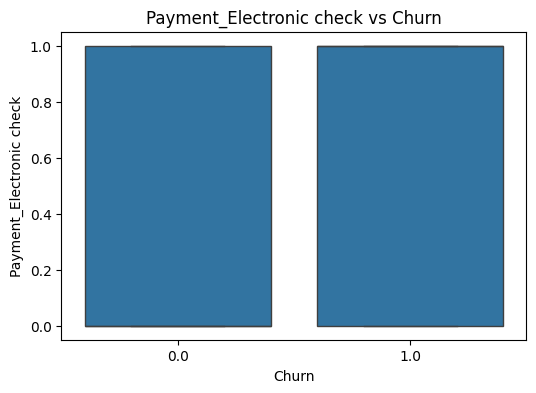

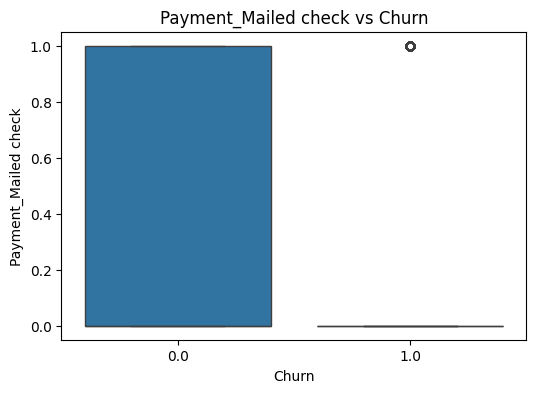

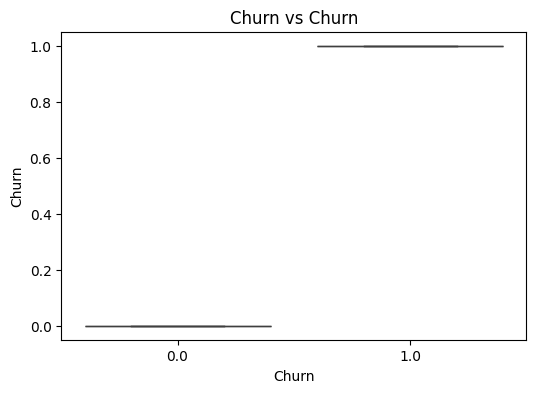

Perbandingan kolom kategorikal dengan Churn:


In [ ]:
# Membagi kolom berdasarkan tipe data
numeric_cols = df_train.select_dtypes(include=['int64', 'float64'])
categorical_cols = df_train.select_dtypes(include=['object']).columns

# Perbandingan untuk kolom numerik
print("Perbandingan kolom numerik dengan Churn:")
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Churn', y=col, data=df_train)
    plt.title(f'{col} vs Churn')
    plt.show()

# Perbandingan untuk kolom kategorikal
print("Perbandingan kolom kategorikal dengan Churn:")
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='Churn', data=df_train)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.show()

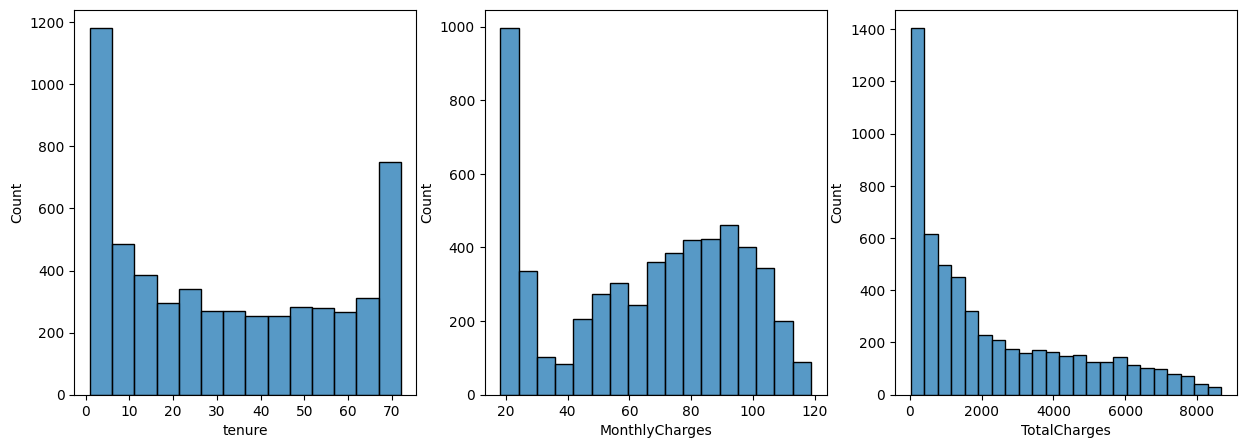

In [ ]:
# tenure, MonthlyCharges, TotalCharges distribution
fig, ax = plt.subplots(1,3, figsize=(15,5))
sns.histplot(df_train['tenure'], ax=ax[0])
sns.histplot(df_train['MonthlyCharges'], ax=ax[1])
sns.histplot(df_train['TotalCharges'], ax=ax[2])
plt.show()

## Feature Engineering

### Checking Outliers

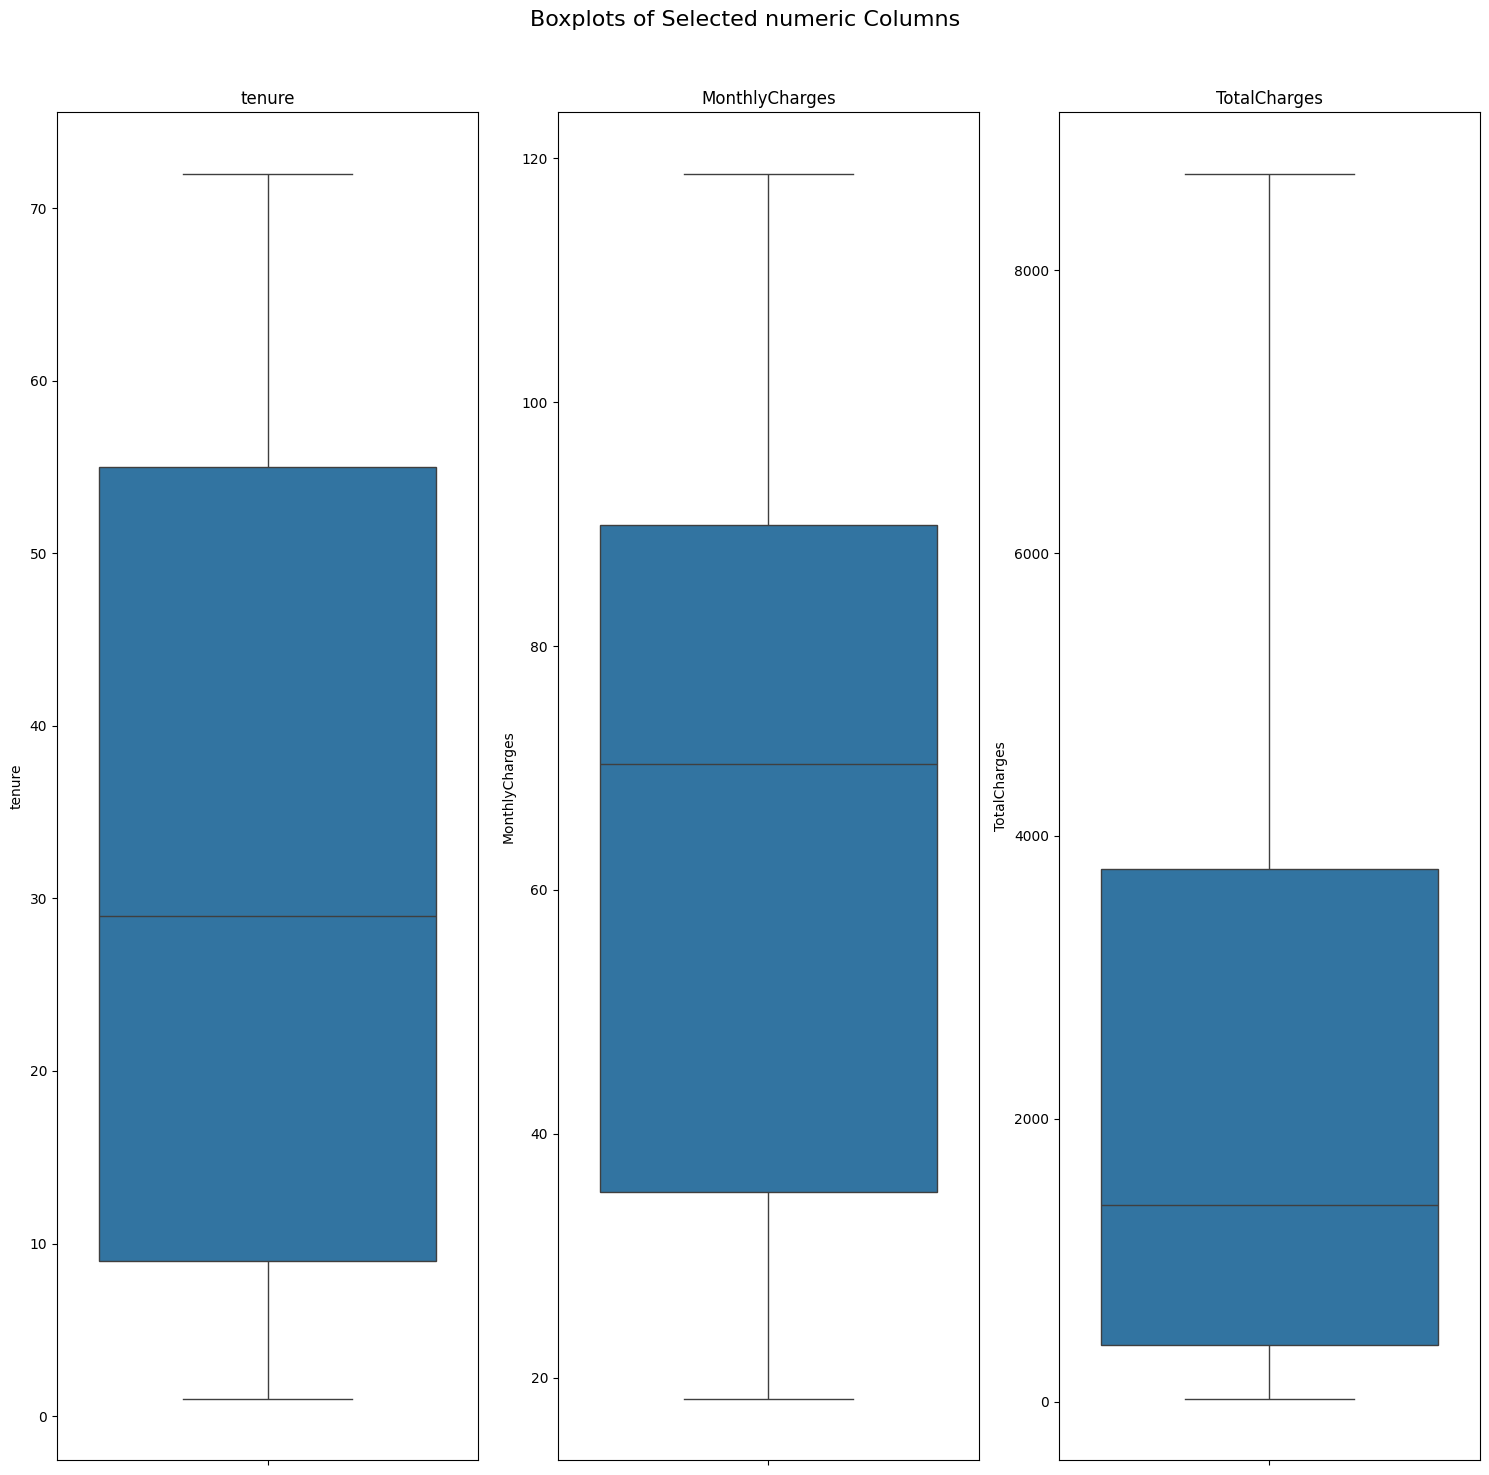

In [ ]:
columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Checking Outliers in every numerical columns
plt.figure(figsize=(15, 15))
plt.suptitle("Boxplots of Selected numeric Columns", fontsize=16)

# Loop through the columns and plot each one as a boxplot
for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_train[col])
    plt.title(col)

# Adjust layout to avoid overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Multicollinearity Check

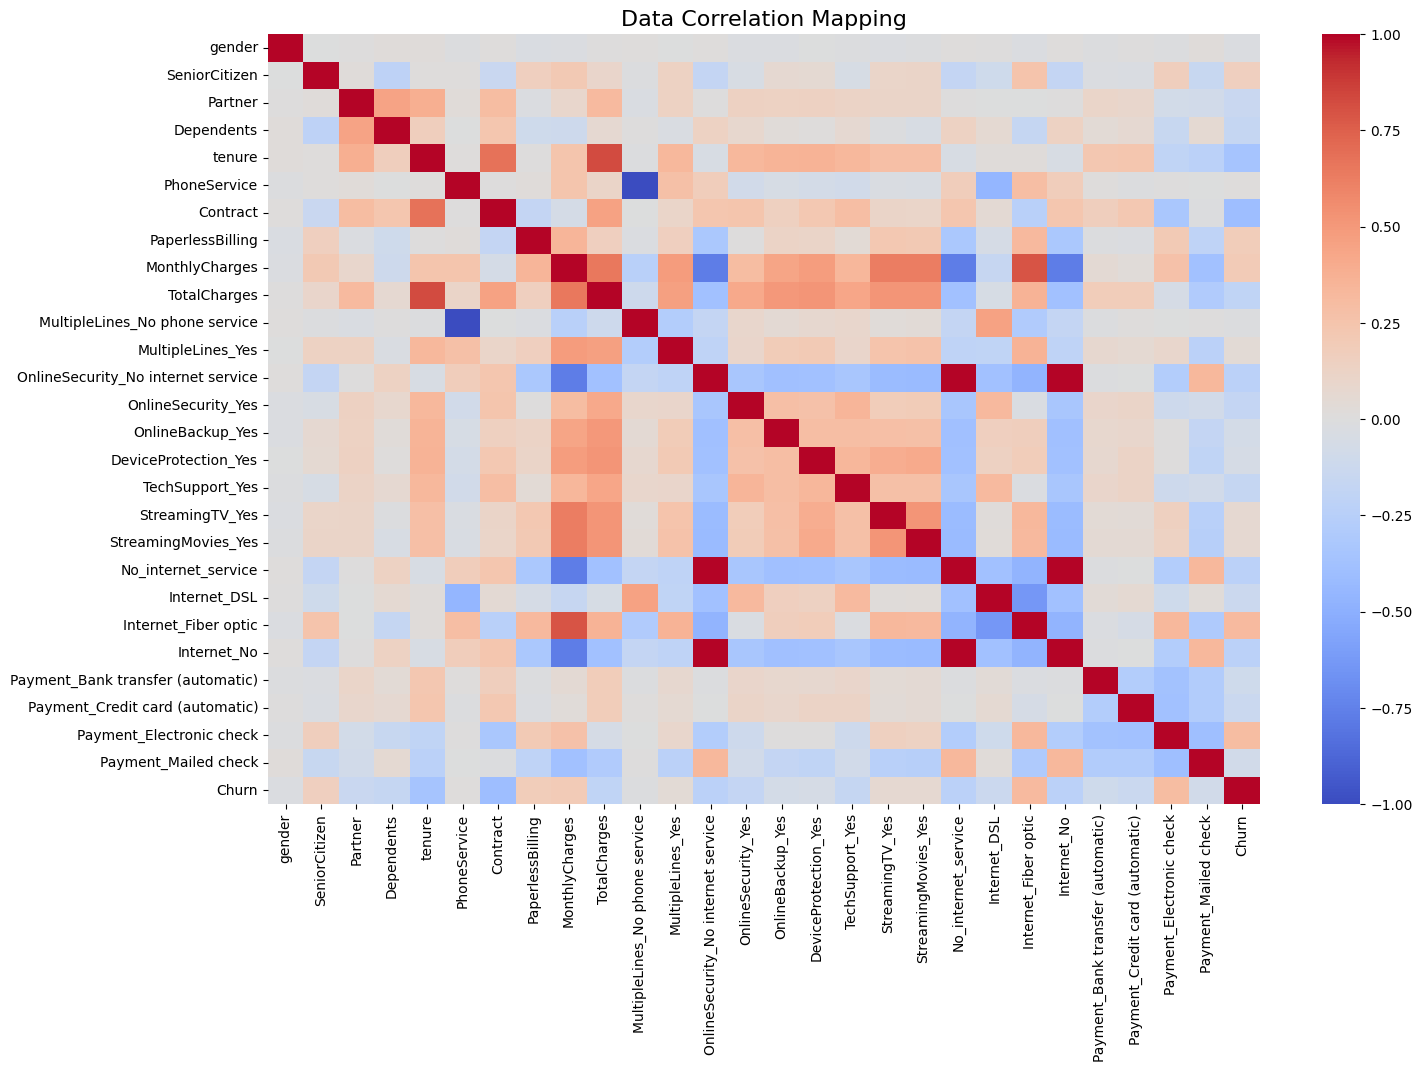

In [ ]:
#Heatmap
df_temp = pd.concat([X_train, y_train], axis=1)
corr_= df_temp.corr()
plt.figure(figsize=(16,10))
sns.heatmap(corr_, cmap = "coolwarm")

plt.title("Data Correlation Mapping", fontsize = 16)
plt.show()

In [ ]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,No_internet_service,Internet_DSL,Internet_Fiber optic,Internet_No,Payment_Bank transfer (automatic),Payment_Credit card (automatic),Payment_Electronic check,Payment_Mailed check
6030,0.0,0.0,0.0,0.0,43.0,0.0,0.0,1.0,49.05,2076.20,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3410,1.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,53.40,188.70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
5483,0.0,0.0,1.0,0.0,55.0,1.0,0.0,1.0,77.75,4458.15,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5524,1.0,0.0,1.0,1.0,45.0,1.0,2.0,0.0,54.65,2553.70,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6337,0.0,0.0,1.0,1.0,55.0,1.0,1.0,0.0,100.90,5448.60,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### Scaling

In [ ]:
#Initialize the scaler (use StandardScaler for standardization or MinMaxScaler for normalization)
scaler = StandardScaler()

# Fit the scaler on the training set and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

4 tree-based model:
- Tahan outliers
- Tahan multicollinearity

Langkah Training Model:
1. Define baseline model
2. Latih Model
3. Predict
3. Tentukan Metriks Evaluasi
4. Cari model lain kalo hasilnya buruk
4. Lakukan Balancing jika perlu
5. Lakukan Hyperparameter tuning

Metrics evaluasi Model Klasifikasi
- Accuracy = Seberapa Akurat Model -> jarang
- Precision = Perbandingan TP dengan TP -> Fokus dengan FP -> semakin besar precisi semakin rendah FP
- Recall = Perbandingan TP dengan FP -> Fokus dengan FN
- F1-Score = skor rata-rata gabungan Precision dan Recall

In [ ]:
# define decision tree model
decision_tree_clf = DecisionTreeClassifier(random_state=42)

# train model
decision_tree_clf.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# predict decision tree model
dt_pred_train = decision_tree_clf.predict(X_train)
dt_pred = decision_tree_clf.predict(X_test)

In [ ]:
report = classification_report(y_train, dt_pred_train, target_names=['0', '1'], output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,accuracy,macro avg,weighted avg
precision,0.997342,0.998654,0.997689,0.997998,0.997691
recall,0.999516,0.992642,0.997689,0.996079,0.997689
f1-score,0.998428,0.995639,0.997689,0.997033,0.997687
support,4130.000000,1495.000000,0.997689,5625.000000,5625.000000


In [ ]:
report = classification_report(y_test, dt_pred, target_names=['0', '1'], output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,accuracy,macro avg,weighted avg
precision,0.820180,0.477833,0.721393,0.649006,0.729179
recall,0.794773,0.518717,0.721393,0.656745,0.721393
f1-score,0.807276,0.497436,0.721393,0.652356,0.724916
support,1033.000000,374.000000,0.721393,1407.000000,1407.000000


Ternyata modelnya overfit

Confusion Matrix:
 [[821 212]
 [180 194]]


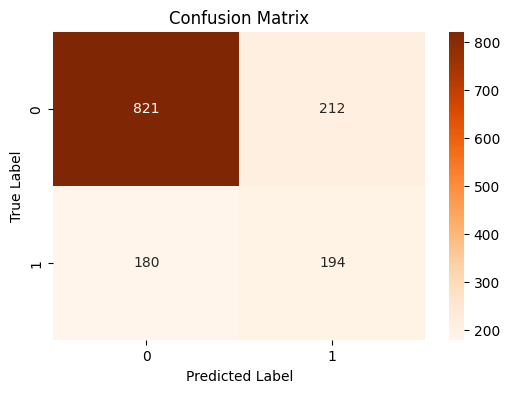

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, dt_pred)
print("Confusion Matrix:\n", conf_matrix)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# define random forest model
random_forest_clf = RandomForestClassifier(
    random_state = 42,
    n_estimators = 100
)
# fit model to training data
random_forest_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# define XGB model
xgb_clf = XGBClassifier(
    random_state = 24
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=24, ...)

In [ ]:
# define LGBM model
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003946 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 632
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151


LGBMClassifier(random_state=42)

In [ ]:
# random forest prediction
rf_train_pred = random_forest_clf.predict(X_train)
rf_pred = random_forest_clf.predict(X_test)

# XGBoost prediction
xgb_train_pred = xgb_clf.predict(X_train)
xgb_pred = xgb_clf.predict(X_test)
xgb_pred_proba = xgb_clf.predict_proba(X_test)

# LGBM prediction
lgbm_train_pred = lgbm.predict(X_train)
lgbm_pred = lgbm.predict(X_test)
lgbm_pred_proba = lgbm.predict_proba(X_test)

In [ ]:
# random forest prediction result
report = classification_report(y_train, rf_train_pred, target_names=['0', '1'], output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,accuracy,macro avg,weighted avg
precision,0.998305,0.995984,0.997689,0.997145,0.997688
recall,0.998547,0.995318,0.997689,0.996932,0.997689
f1-score,0.998426,0.995651,0.997689,0.997039,0.997689
support,4130.000000,1495.000000,0.997689,5625.000000,5625.000000


In [ ]:
# random forest prediction result
report = classification_report(y_test, rf_pred, target_names=['0', '1'], output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,accuracy,macro avg,weighted avg
precision,0.829268,0.616667,0.783937,0.722967,0.772756
recall,0.888674,0.494652,0.783937,0.691663,0.783937
f1-score,0.857944,0.548961,0.783937,0.703453,0.775812
support,1033.000000,374.000000,0.783937,1407.000000,1407.000000


In [ ]:
# XGBoost prediction result
report = classification_report(y_test, xgb_pred, target_names=['0','1'], output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,accuracy,macro avg,weighted avg
precision,0.822284,0.563863,0.763326,0.693073,0.753592
recall,0.864472,0.483957,0.763326,0.674215,0.763326
f1-score,0.842850,0.520863,0.763326,0.681857,0.757262
support,1033.000000,374.000000,0.763326,1407.000000,1407.000000


In [ ]:
# LGBM prediction result
report = classification_report(y_test, lgbm_pred, target_names=['0','1'], output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,accuracy,macro avg,weighted avg
precision,0.827899,0.607261,0.780384,0.71758,0.769250
recall,0.884802,0.491979,0.780384,0.68839,0.780384
f1-score,0.855405,0.543575,0.780384,0.69949,0.772516
support,1033.000000,374.000000,0.780384,1407.00000,1407.000000


Confusion Matrix:
 [[918 115]
 [189 185]]


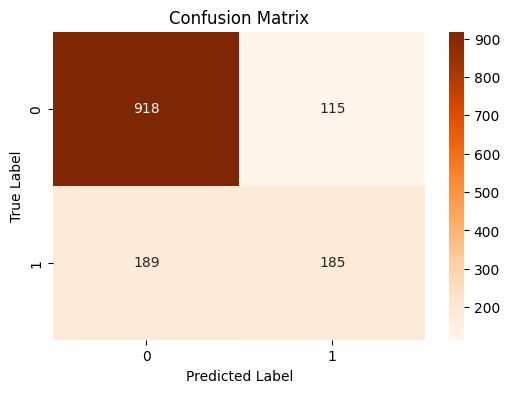

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:\n", conf_matrix)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix:
 [[893 140]
 [193 181]]


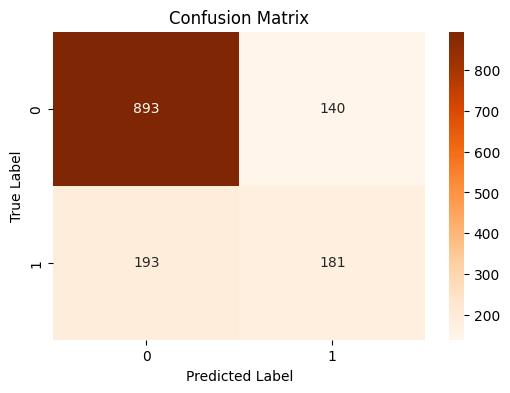

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, xgb_pred)
print("Confusion Matrix:\n", conf_matrix)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix:
 [[914 119]
 [190 184]]


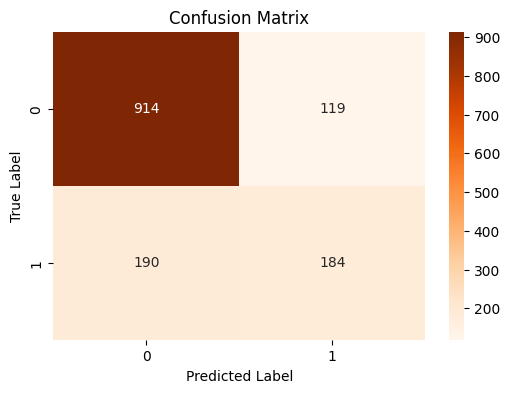

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, lgbm_pred)
print("Confusion Matrix:\n", conf_matrix)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
# define decision tree model
decision_tree_clf = DecisionTreeClassifier(random_state=42)

# train model
decision_tree_clf.fit(X_resampled,y_resampled)

DecisionTreeClassifier(random_state=42)

In [ ]:
# LGBM Test prediction
dt_smote_pred = decision_tree_clf.predict(X_test)
# LGBM prediction result
report = classification_report(y_test, dt_smote_pred, target_names=['0', '1'], output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,accuracy,macro avg,weighted avg
precision,0.817452,0.468293,0.715707,0.642873,0.724641
recall,0.788964,0.513369,0.715707,0.651167,0.715707
f1-score,0.802956,0.489796,0.715707,0.646376,0.719713
support,1033.000000,374.000000,0.715707,1407.000000,1407.000000


## Hyperparameter tuning

In [ ]:
%%time
# Hyperparameter tuning for Decision Tree
from sklearn.model_selection import GridSearchCV
# Initialize DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],       # Function to measure the quality of a split
    'splitter': ['best', 'random'],                    # Strategy used to split at each node
    'max_depth': [None, 3, 5, 10],                     # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],                   # Minimum number of samples to split a node
    'min_samples_leaf': [1, 2, 5],                     # Minimum number of samples at a leaf node
    'max_features': [None, 'sqrt', 'log2'],            # Number of features to consider for the best split
    'ccp_alpha': [0.0, 0.01, 0.1]                      # Complexity parameter for minimal cost-complexity pruning
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best hyperparameters and corresponding score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


Best hyperparameters: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Best cross-validation score: 0.7244147157190636
CPU times: user 10.1 s, sys: 1.28 s, total: 11.4 s
Wall time: 3min 1s


In [ ]:

# Evaluate on the test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test set accuracy:", test_score)

Test set accuracy: 0.7192608386638237


In [ ]:
# Predict with best model
y_pred = best_model.predict(X_test)
# LGBM prediction result
report = classification_report(y_test, y_pred, target_names=['0', '1'], output_dict=True)
report_df = pd.DataFrame(report)
report_df

,0,1,accuracy,macro avg,weighted avg
precision,0.879762,0.481481,0.719261,0.680622,0.773893
recall,0.715392,0.729947,0.719261,0.722669,0.719261
f1-score,0.789108,0.580234,0.719261,0.684671,0.733587
support,1033.000000,374.000000,0.719261,1407.000000,1407.000000


## Explanatory Model Analysis

In [ ]:
## initiate explainer for best model
best_model_exp = dx.Explainer(best_model, X_train, y_train, label = "Model Interpretation")

Preparation of a new explainer is initiated

  -> data              : 5625 rows 27 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 5625 values
  -> model_class       : sklearn.tree._classes.DecisionTreeClassifier (default)
  -> label             : Model Interpretation
  -> predict function  : <function yhat_proba_default at 0x79184c494b80> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0287, mean = 0.266, max = 0.526
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.526, mean = -1.31e-17, max = 0.971
  -> model_info        : package sklearn

A new explainer has been created!


In [ ]:
# visualize permutation feature importance for best model
best_model_exp.model_parts().plot()

seberapa besar dampak

In [ ]:
# create partial dependence plot of RF model
best_model_exp.model_profile().plot()

Calculating ceteris paribus: 100%|██████████| 27/27 [00:00<00:00, 35.59it/s]
